In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import random
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_dir = '../../../data/mujoco/hopper'
model_dir = '../../../models/mujoco/hopper'
result_dir = '../../../results/mujoco/hopper'

data_suffix = '1x'

In [2]:
# --! initialize random seed

seeds = [5, 44, 123, 1024, 2026]
seed = seeds[4]

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)

### Creating baseline dataset

In [3]:
data_nsample = 918
data = util_data.read_datafile(f'{data_dir}/baseline_{data_suffix}', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 11
act_ndim = 3
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataloaders = []
nmodel = 7

for _ in range(nmodel):
    dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
    dataloaders.append(torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True))


read data shape: torch.Size([40, 918, 14])
read observations shape: torch.Size([40, 918, 11])
read actions shape: torch.Size([40, 918, 3])
shape of observations for training: torch.Size([40, 917, 11])
shape of next observations for training: torch.Size([40, 917, 11])
shape of actions for training: torch.Size([40, 917, 3])


### Training ensemble dynamics

In [4]:
model = example_mujoco.model_ensemble(nmodel, obs_ndim, act_ndim)
example_mujoco.train_ensemble(model, dataloaders, nepoch=300)

0 [array([-0.06169809]), array([-0.06120572]), array([-0.06030235]), array([-0.06304853]), array([-0.05844815]), array([-0.05806386]), array([-0.06084393])]
10 [array([-0.20492981]), array([-0.20234868]), array([-0.20889536]), array([-0.21969821]), array([-0.20125273]), array([-0.20133943]), array([-0.20996162])]
20 [array([-0.50874918]), array([-0.47656335]), array([-0.46530196]), array([-0.47920683]), array([-0.48310317]), array([-0.50460618]), array([-0.51675354])]
30 [array([-0.61340032]), array([-0.57977009]), array([-0.58510658]), array([-0.61913245]), array([-0.5904524]), array([-0.43392069]), array([-0.59184653])]
40 [array([-0.60801758]), array([-0.63455554]), array([-0.60328041]), array([-0.6608651]), array([-0.65526513]), array([-0.64543772]), array([-0.63907691])]
50 [array([-0.67658022]), array([-0.65113524]), array([-0.63148975]), array([-0.63121523]), array([-0.64985568]), array([-0.63967936]), array([-0.59780468])]
60 [array([-0.55204483]), array([-0.63863148]), array([

In [5]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters in model ensemble: {nparam/1e6}M')

number of trainable parameters in model ensemble: 0.527156M


In [6]:
modelsaved = False

if modelsaved:
    for j, m in enumerate(model.models):
        torch.save(m.state_dict(), f'{model_dir}/ensemble_checkpoint_{data_suffix}_{nmodel}_{j}.pth')

# Evaluating ensemble baseline

In [7]:
eval_data = util_data.read_datafile(f'{data_dir}/eval', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

model.eval()

read evaluation data shape: torch.Size([30, 918, 14])
read evaluation observations shape: torch.Size([30, 918, 11])
read evaluation actions shape: torch.Size([30, 918, 3])


In [8]:
this_traj = 0
deterministic = True
reanchor_nsample = 1_000_000 # ensure no re-anchoring

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_ensemble(
    model, s0,
    eval_obs[this_traj], eval_act[this_traj],
    deterministic=deterministic, reanchor_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 11])


### Plotting rollout results

In [9]:
def disp_rollout(obs_true, obs_rollout, obs_mean, obs_std, this_traj=0, disp_end=300):

    with torch.no_grad():
        plot_rollout_traj = torch.unsqueeze(obs_rollout, 0)
        plot_rollout_traj = torch.cat([
            example_mujoco.denormalize_standard(
                s, mean, std) for s, mean, std in zip(torch.split(plot_rollout_traj, 1, dim=-1), obs_mean, obs_std)], dim=-1)
        plot_obs = torch.cat([
            example_mujoco.denormalize_standard(
                s, mean, std) for s, mean, std in zip(torch.split(obs_true, 1, dim=-1), obs_mean, obs_std)], dim=-1)

        #plot_rollout_traj[:, 410:, :1] = 5.0
        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(plot_obs[this_traj, :disp_end, 0], label='z')
        plt.plot(plot_rollout_traj[0, :disp_end, 0])
        plt.ylim((-1,3))
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(plot_obs[this_traj, :disp_end, 9], label='dz')
        plt.plot(plot_rollout_traj[0, :disp_end, 9])
        plt.legend()

        plt.show()

    return plot_obs, plot_rollout_traj

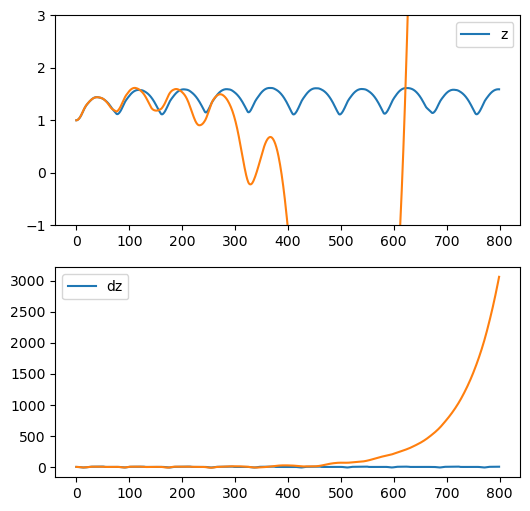

In [10]:
disp_end = 800
datasaved = True

plot_obs, plot_rollout = disp_rollout(eval_obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_step = torch.arange(eval_obs.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [6]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [6]]], axis=2)
    util_data.write_datafile(f'{result_dir}/ensemble_rollout_{data_suffix}_{rollout_type}_{nmodel}_{seed}', savedata, delim=' ')

### Analyzing mse vs. rollout horizon

In [11]:
# --! compute MSE vs. horizon

traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            cmp_rollout = example_mujoco.rollout_ensemble(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h],
                deterministic=deterministic, reanchor_nsample=reanchor_nsample)

            # --! denormalize results
            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(eval_obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)

            # --! compute error
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {eval_obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)

processing trajectory 1 out of 30
	horizon 100 out of 918, loss: 0.4834091365337372
	horizon 200 out of 918, loss: 1.649487853050232
	horizon 300 out of 918, loss: 4.390472412109375
	horizon 400 out of 918, loss: 45.956668853759766
	horizon 500 out of 918, loss: 562.44580078125
	horizon 600 out of 918, loss: 8057.5458984375
	horizon 700 out of 918, loss: 141892.6875
	horizon 800 out of 918, loss: 2608722.5
	horizon 900 out of 918, loss: 49701356.0
processing trajectory 2 out of 30
	horizon 100 out of 918, loss: 0.4372275471687317
	horizon 200 out of 918, loss: 1.539791464805603
	horizon 300 out of 918, loss: 4.758014678955078
	horizon 400 out of 918, loss: 58.85547637939453
	horizon 500 out of 918, loss: 767.7637329101562
	horizon 600 out of 918, loss: 10763.087890625
	horizon 700 out of 918, loss: 184213.71875
	horizon 800 out of 918, loss: 3366093.5
	horizon 900 out of 918, loss: 63795932.0
processing trajectory 3 out of 30
	horizon 100 out of 918, loss: 2.646331787109375
	horizon 20

tensor(0.0069)
tensor(0.0079)


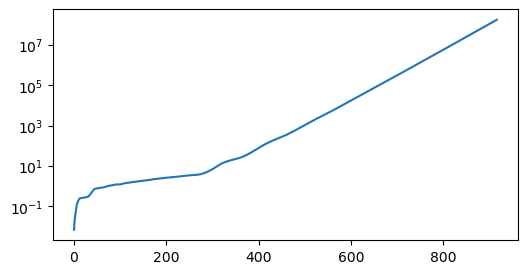

In [12]:
# --! plot MSE vs. horizon

traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.show()

datasaved = True
if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/ensemble_mse_{data_suffix}_{rollout_type}_{nmodel}_{seed}', savedata, delim=' ')

In [15]:
def read_datafile(name: str, datachunk_len, delim=' ') -> torch.Tensor:
    """
    Reads data from a file called ``name`` and formats the data based on ``datachunk_len``,
    i.e. the length of one contiguous chunk of data. The file data are expected to be
    in format [T, C], such that the read data could be formatted as [B, T, C],
    where B, T and C are the number of batches, time steps and data channels,
    repectively.
    """

    # --! note that we force numpy loadtxt to return at least a two-dimensional array
    # --! by setting ndmin=2
    data = torch.tensor(
        np.loadtxt(name + '.csv', delimiter=delim, dtype=np.float32, ndmin=2))
    datachunks_n = int(data.shape[0] / datachunk_len)

    # return read data in channels-last format
    return torch.reshape(data, (datachunks_n, datachunk_len, data.shape[1]))

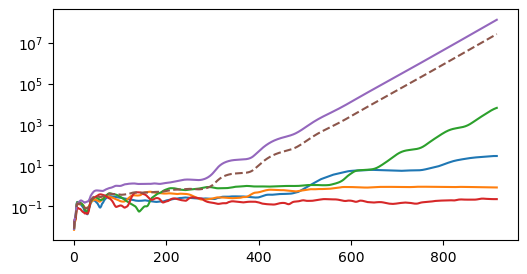

In [16]:
mseprocessed = False

if mseprocessed:
    mse_data = [
        read_datafile(f'{result_dir}/ensemble_mse_1x_deterministic_7_{s}', len(traj_mse_mean)) for s in seeds]
    mse = torch.cat([mse[..., [2]] for mse in mse_data], dim=0)
    mse_avg = torch.mean(mse, dim=0, keepdim=True)

    plt.figure(figsize=(6,3))
    for j in range(mse.shape[0]):
        plt.semilogy(mse[j, :, 0])
    plt.semilogy(mse_avg[0, :, 0], linestyle='dashed')
    plt.show()

    horizon = disp_end
    nmse = mse.shape[0]
    save_step = torch.arange(mse_avg.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :horizon, :1],
        mse_avg[:1, :horizon, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/ensemble_mse_1x_deterministic_7_avg_{nmse}', savedata, delim=' ')